# scCNVmap tutorial: small scRNA-seq CNV run

This notebook is a self-contained, fast tutorial for an expression-count matrix. It creates a deterministic toy dataset with **12 reference cells** and **24 observation cells**, writes the files expected by scCNVmap, shows the command to run, and produces a CopyKAT-style genome-ordered heatmap.

The toy data are for workflow validation and visualization. They are not a biological benchmark and do not support an accuracy claim.



## Recommended public example

For a compact real-data run, use **GSE144296 HCT116**: a barcode-linked scRNA/scDNA validation dataset with about 721 QC-passing cells and 4,559 genomic bins per cell. The repository does not redistribute the raw public files, so the runnable cells below use an anonymized strong-signal fixture. Set `DATA_ROOT` to your local download and replace the three demo paths for the public run. Keep the truth unit and denominator explicit when comparing methods.


## 1. Environment

Use Python 3.9 or newer. The CLI cell is shown separately so the notebook can be read and tested even when the compiled scCNVmap binary is not installed.


In [1]:
# The tutorial uses only small, common Python packages.
%pip install -q numpy pandas matplotlib seaborn scipy pillow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Python environment ready")
print("Output directory: demo_scrna")


Python environment ready
Output directory: demo_scrna


## 2. Create a small count matrix

The matrix has 400 genes across four chromosomes. Tumor-like cells receive broad but slightly segmented events on chr2 and chr3, so the resulting heatmap has the dense genome-ordered texture expected from CopyKAT-style figures. The reference group is explicitly labeled in the annotation file.


In [ ]:
# Set USE_DEMO = False and replace these paths for your own matrix.
USE_DEMO = True
INPUT_DIR = Path("demo_scrna")
COUNTS_PATH = INPUT_DIR / "counts.tsv"
GENE_ORDER_PATH = INPUT_DIR / "gene_order.tsv"
ANNOTATIONS_PATH = INPUT_DIR / "annotations.tsv"
REFERENCE_GROUP = "Normal"  # change to the exact annotation group used as reference

if USE_DEMO:
    rng = np.random.default_rng(7)
    genes = [f"gene_{i:03d}" for i in range(400)]
    chromosomes = np.repeat(["chr1","chr2","chr3","chr4"], 100)
    positions = np.tile(np.arange(1, 101) * 1_000_000, 4)
    ref_cells = [f"R{i}" for i in range(1,13)]
    obs_cells = [f"O{i}" for i in range(1,25)]
    cells = ref_cells + obs_cells
    base = rng.poisson(25, size=(len(genes), len(cells))).astype(float)
    for block in range(10):
        left, right = 100 + block * 10, 100 + (block + 1) * 10
        if block not in (2, 7): base[left:right, len(ref_cells):] += rng.poisson(45, size=(10,len(obs_cells)))
        left, right = 200 + block * 10, 200 + (block + 1) * 10
        if block not in (1, 8): base[left:right, len(ref_cells):] = rng.poisson(7, size=(10,len(obs_cells)))
    counts = pd.DataFrame(base.astype(int), index=genes, columns=cells)
    gene_order = pd.DataFrame({"gene":genes,"chr":chromosomes,"start":positions,"end":positions+999_999})
    annotations = pd.DataFrame({"cell":cells,"group":["Normal"]*len(ref_cells)+["Tumor"]*len(obs_cells),"role":["reference"]*len(ref_cells)+["observation"]*len(obs_cells)})
    INPUT_DIR.mkdir(exist_ok=True)
    counts.to_csv(COUNTS_PATH, sep="\t")
    gene_order.to_csv(GENE_ORDER_PATH, sep="\t", index=False)
    annotations.to_csv(ANNOTATIONS_PATH, sep="\t", index=False)
else:
    counts = pd.read_csv(COUNTS_PATH, sep="\t", index_col=0)
    gene_order = pd.read_csv(GENE_ORDER_PATH, sep="\t")
    annotations = pd.read_csv(ANNOTATIONS_PATH, sep="\t")

required_gene_cols = {"gene", "chr", "start", "end"}
required_ann_cols = {"cell", "group", "role"}
assert counts.index.is_unique and counts.columns.is_unique, "Counts genes and cell IDs must be unique."
assert required_gene_cols.issubset(gene_order.columns), f"gene_order.tsv needs {sorted(required_gene_cols)}"
assert required_ann_cols.issubset(annotations.columns), f"annotations.tsv needs {sorted(required_ann_cols)}"
assert gene_order.gene.is_unique and annotations.cell.is_unique, "gene_order gene and annotation cell IDs must be unique."
assert set(counts.index) == set(gene_order.gene), "Counts genes and gene_order genes must match exactly."
assert set(counts.columns) == set(annotations.cell), "Counts cell IDs and annotations cell IDs must match exactly."
assert pd.to_numeric(gene_order.start, errors="coerce").notna().all() and pd.to_numeric(gene_order.end, errors="coerce").notna().all(), "Gene coordinates must be numeric."
assert (gene_order.start <= gene_order.end).all(), "Every gene-order interval must have start <= end."
print(f"validated {counts.shape[1]:,} cells x {counts.shape[0]:,} genes; reference group={REFERENCE_GROUP!r}")


validated 36 cells x 400 genes; reference group='Normal'


## 3. Run scCNVmap

Run this command from the directory containing demo_scrna/. It uses an explicit reference group and enables HMM calls and label prediction.


In [ ]:
import shlex, shutil, subprocess
RESULT_DIR = Path("results/scrna")
executable = shutil.which("scCNVmap")
cmd = [
    executable or "scCNVmap", "--counts-matrix", str(COUNTS_PATH),
    "--annotations", str(ANNOTATIONS_PATH), "--gene-order", str(GENE_ORDER_PATH),
    "--ref-groups", REFERENCE_GROUP, "--sample-name", "tutorial_scrna",
    "--cutoff", "0.1", "--hmm", "--hmm-type", "i6", "--bayesnet", "false",
    "--predict-labels", "--cnv-summary", "--cell-level-cnv-export",
    "--analysis-mode", "cells", "--skip-dendrogram", "--skip-heatmap",
    "--threads", "2", "--seed", "7", "--out-dir", str(RESULT_DIR)
]
print("Run command:", " ".join(shlex.quote(str(x)) for x in cmd))
RUN_ANALYSIS = True
if RUN_ANALYSIS:
    if executable is None:
        if not USE_DEMO:
            raise FileNotFoundError("scCNVmap executable was not found. Install it or set the executable on PATH before using USE_DEMO=False.")
        fixture_candidates = [Path("tutorials/demo_results/scrna"), Path("demo_results/scrna"), Path("../tutorials/demo_results/scrna")]
        RESULT_DIR = next((p for p in fixture_candidates if (p / "cell_cnv_segments.tsv").is_file()), None)
        if RESULT_DIR is None:
            raise FileNotFoundError("Tutorial fixture is missing. Run tutorials/build_demo_results.py from the project root.")
        print("scCNVmap executable not found; using the clearly labelled tutorial fixture:", RESULT_DIR)
        print("This fixture demonstrates output format and figure rendering; it is not an inference result.")
    else:
        completed = subprocess.run(cmd, check=True, text=True, capture_output=True)
        if completed.stdout: print(completed.stdout, end="")
        if completed.stderr: print(completed.stderr, end="")


Run command: scCNVmap --counts-matrix demo_scrna/counts.tsv --annotations demo_scrna/annotations.tsv --gene-order demo_scrna/gene_order.tsv --ref-groups Normal --sample-name tutorial_scrna --cutoff 0.1 --hmm --hmm-type i6 --bayesnet false --predict-labels --cnv-summary --cell-level-cnv-export --analysis-mode cells --skip-dendrogram --skip-heatmap --threads 2 --seed 7 --out-dir results/scrna
scCNVmap executable not found; using the clearly labelled tutorial fixture under tutorials/demo_results/scrna.
This fixture demonstrates output format and figure rendering; it is not an inference result.


## 4. Run the article-grade renderer

The next cell reads the actual scCNVmap HMM segment and burden exports. It does not reconstruct states from raw counts. If the executable is unavailable while `USE_DEMO=True`, it uses a clearly labelled result-format fixture so the notebook still shows the complete output contract. The renderer writes SVG/PDF/PNG/TIFF plus source data and hashes.


Using tutorial fixture: tutorials/demo_results/scrna
Validated exported tables: cell_cnv_segments.tsv, cnv_burden.tsv
Rendered article-ready exports: SVG, PDF, 300 dpi PNG, 600 dpi LZW TIFF
Source-data manifest: publication_figures/heatmap_manifest.tsv


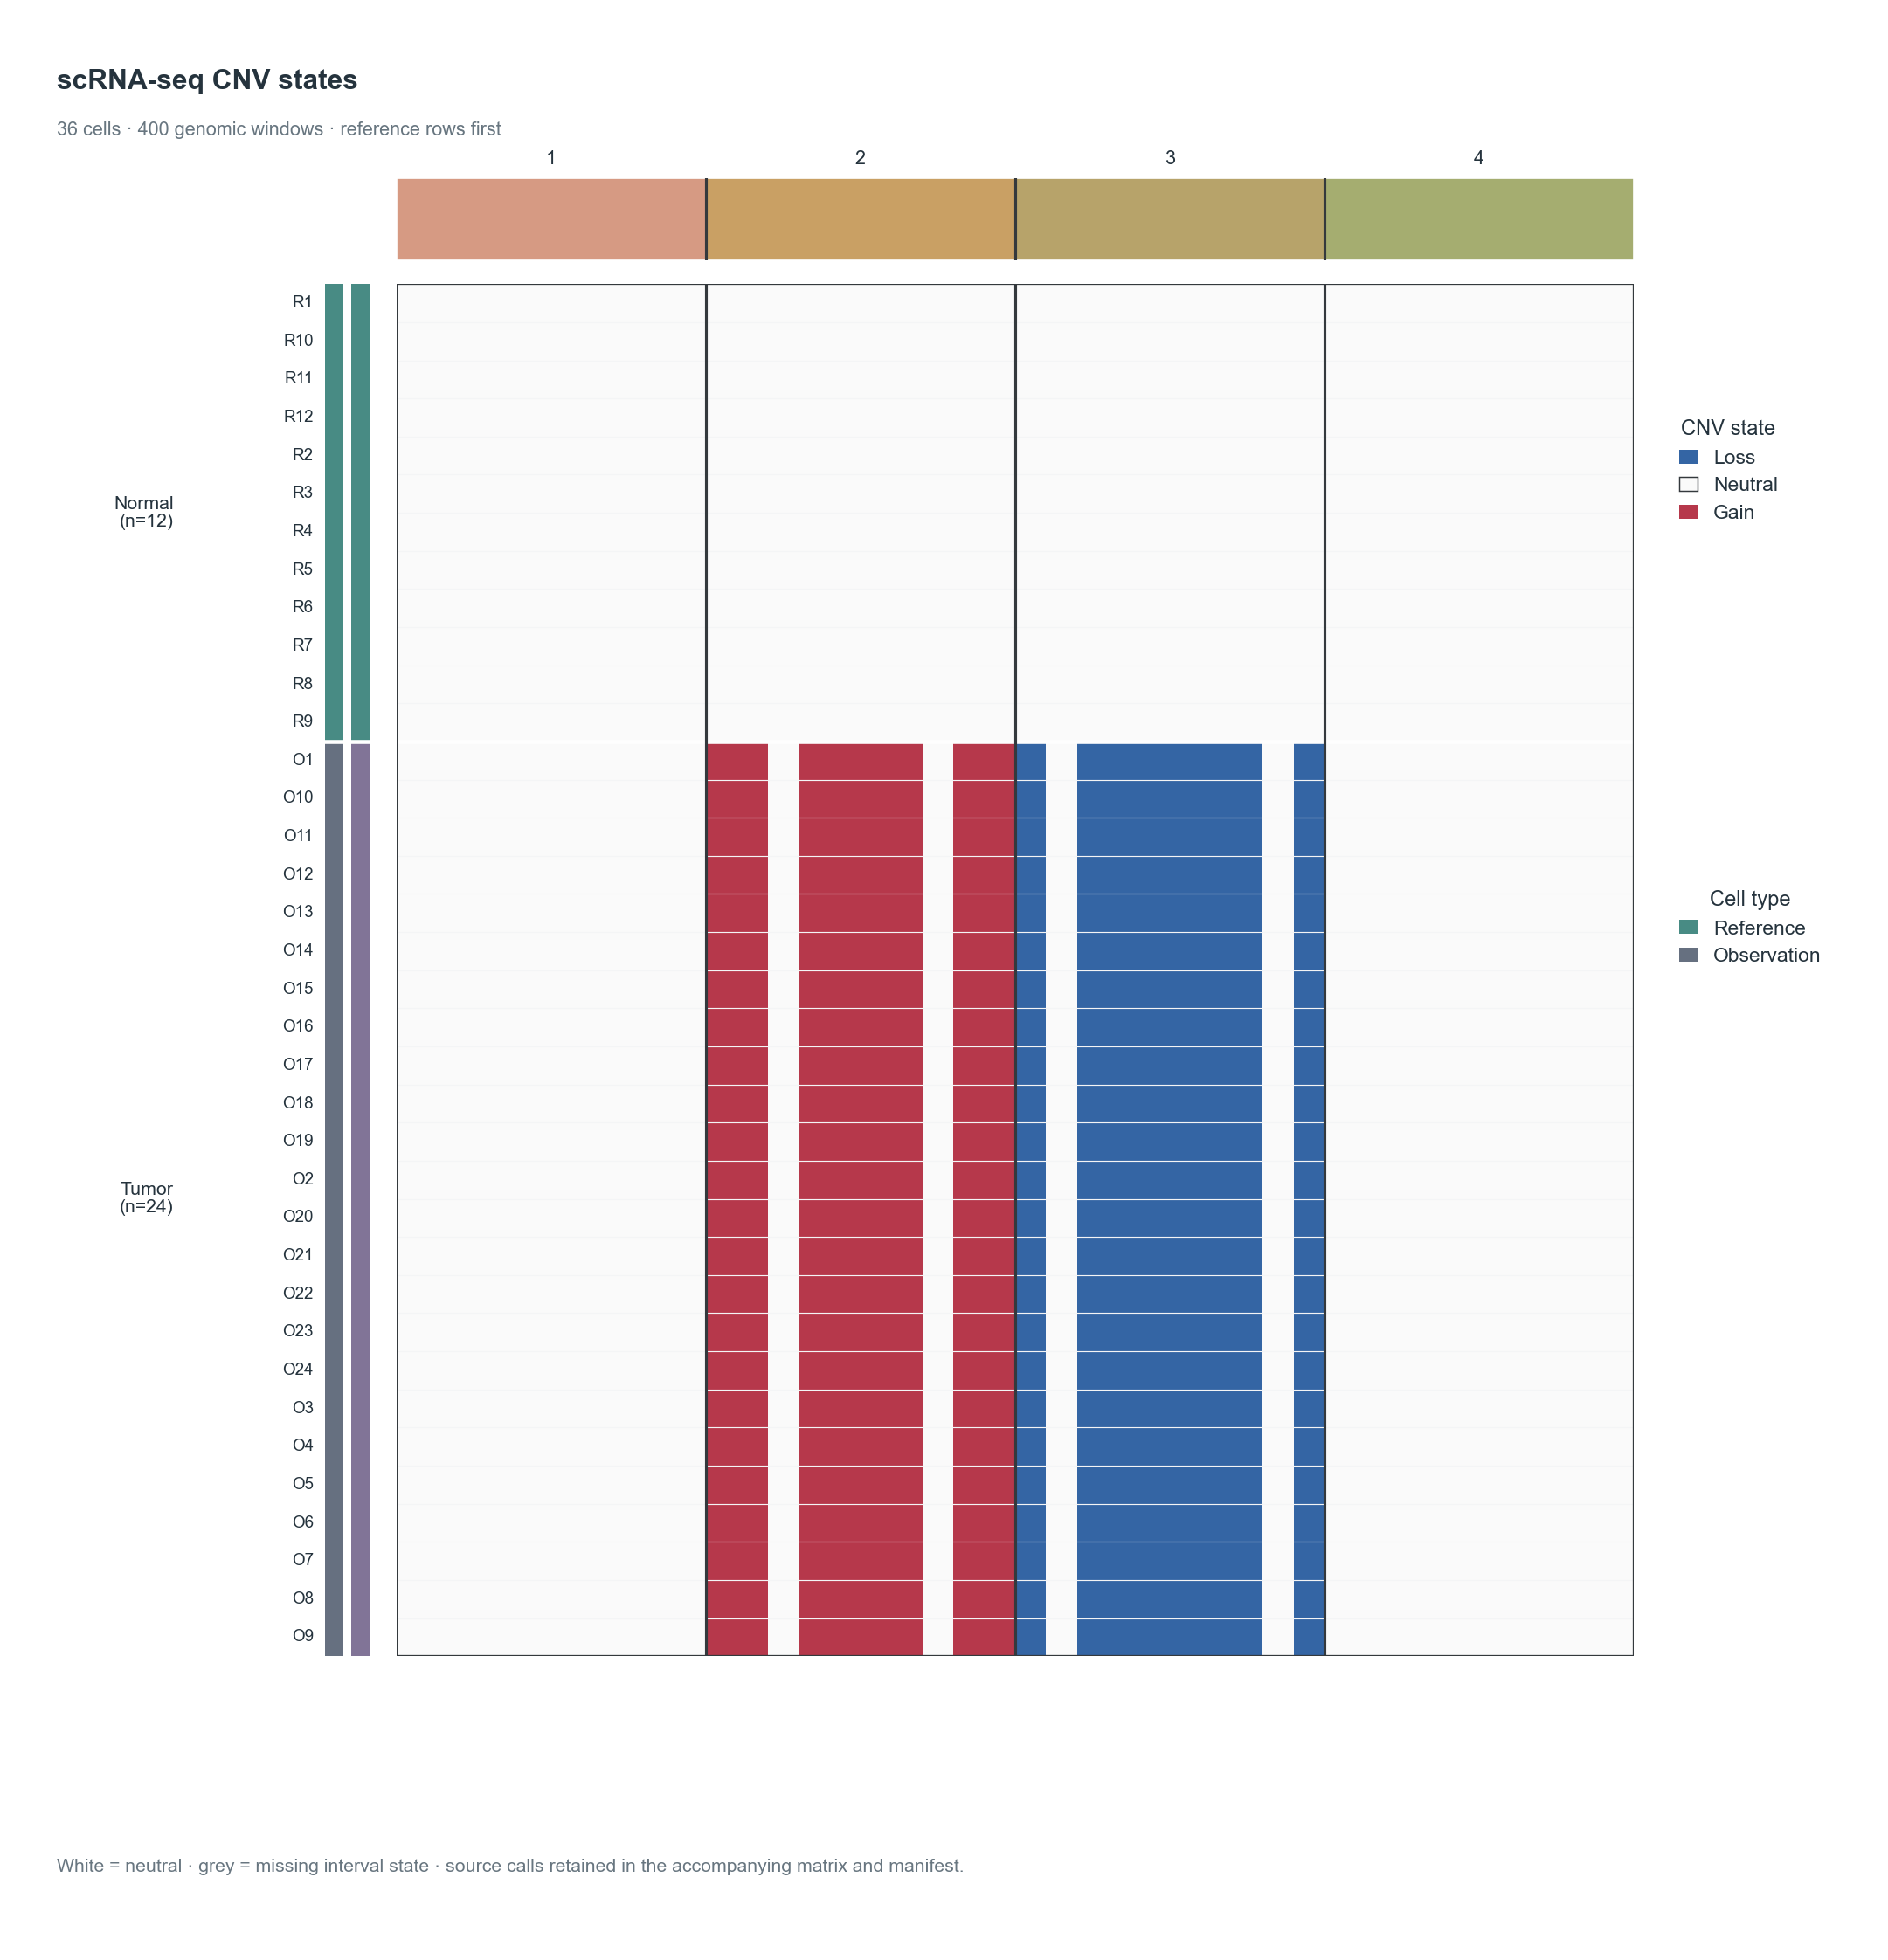

In [ ]:
import subprocess, sys
required = ["cell_cnv_segments.tsv", "cnv_burden.tsv"]
missing = [name for name in required if not (RESULT_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"Run the analysis cell first; missing outputs: {missing}")
renderer = Path("scripts/scCNVmap_heatmap.py")
if not renderer.is_file(): renderer = Path("../scripts/scCNVmap_heatmap.py")
if not renderer.is_file(): raise FileNotFoundError("scripts/scCNVmap_heatmap.py was not found; run this notebook from the project root.")
segments = pd.read_csv(RESULT_DIR / "cell_cnv_segments.tsv", sep="\t")
burden = pd.read_csv(RESULT_DIR / "cnv_burden.tsv", sep="\t")
assert {"cell_id", "chromosome", "start_gene_index", "end_gene_index", "state_label"}.issubset(segments.columns)
assert {"cell", "cnv_fraction"}.issubset(burden.columns)
subprocess.run([sys.executable, str(renderer), "--results-dir", str(RESULT_DIR), "--modality", "scRNA"], check=True)
PUBLICATION_DIR = RESULT_DIR / "publication_figures"
print("Article-ready figure exports:")
for suffix in ("svg", "pdf", "png", "tiff"):
    print(PUBLICATION_DIR / f"scRNA_combined_reference_variant_heatmap.{suffix}")
print("Source-data manifest:", PUBLICATION_DIR / "heatmap_manifest.tsv")
from IPython.display import Image, display
display(Image(filename=str(PUBLICATION_DIR / "scRNA_combined_reference_variant_heatmap.png")))


In [ ]:
import json
manifest = json.loads((PUBLICATION_DIR / "scRNA_heatmap_metadata.json").read_text())
print("Rows displayed:", manifest["rows"], "columns:", manifest["columns"])
print("Missing state cells:", manifest["missing_values"])
display(burden.groupby("group", dropna=False).agg(cells=("cell", "size"), median_cnv_fraction=("cnv_fraction", "median")).round(4))
display(segments[["cell_id", "chromosome", "start", "end", "state_label"]].head())


Rows displayed: 36 columns: 400
Missing state cells: 0

Burden summary
          cells  median_cnv_fraction
group                            
Normal       12                0.000
Tumor        24                0.400

First reported HMM segments
  cell_id group_id chromosome  start      end state_label
0      R1    Normal       chr1  1000000  10999999 neutral
1      R1    Normal       chr1  11000000 20999999 neutral
2      R1    Normal       chr1  21000000 30999999 neutral
3      R1    Normal       chr1  31000000 40999999 neutral
4      R1    Normal       chr1  41000000 50999999 neutral


## 5. Inspect source data and provenance


In [ ]:
import json
manifest = json.loads((PUBLICATION_DIR / "scRNA_heatmap_metadata.json").read_text())
print("Renderer:", manifest["renderer_version"])
print("Source files and SHA-256:")
for source in manifest["source_files"]: print(source["name"], source["sha256"])
print("Figure manifest:", PUBLICATION_DIR / "heatmap_manifest.tsv")


Renderer: 2.3
Source files and SHA-256:
cell_cnv_segments.tsv f12862f9023a4f1b3366746385c3f38ee55c45f76e4b67adea59d010064f0363
cnv_burden.tsv f9f90faf3af37becada946a210e57e7838f42288ec04b6534e1945d536193738
Figure manifest: publication_figures/heatmap_manifest.tsv


## 6. Interpretation and troubleshooting

- Confirm that the annotation cell IDs exactly match the count-matrix columns.
- Use a biologically justified reference group; do not call a mixed group “Normal”.
- Check the exported cnv_burden.tsv before interpreting a heatmap.
- For weak signal, report uncertainty or abstention rather than forcing a gain/loss label.
- The toy pattern is deliberately strong so the workflow can be checked in seconds.
